# A spin echo, and the one rule that makes it one

A refocusing pulse **conjugates k**. Everything in this notebook is one consequence of that:

> Between consecutive refocusing centres, each axis's gradient area *before* the echo equals its
> area *after* it. And the area from the excitation's centre to the first refocusing centre equals
> the area from that centre to the first echo.

Writing $A(t_1 \to t_2)$ for the area on one axis and $t^{\mathrm{ref}}_n$ for the **effective
centre** of refocusing pulse $n$,

$$k_n \;=\; -\big(k_{n-1} + A(\mathrm{echo}_{n-1} \to t^{\mathrm{ref}}_n)\big) \;+\; A(t^{\mathrm{ref}}_n \to \mathrm{echo}_n)$$

so $k_n = k_{n-1} = 0$ exactly when the two areas are equal.

**Two passes.** The shot composed out of modules with every offset written out, then the same
composition as `SE2D`, asserted to produce identical events. One module ships out of it —
`Refocusing` — plus one boolean on `CartesianLine`; `SE2D` has one consumer, which is this
notebook, and stays here.

`sc.kspace()` is the oracle throughout, because it applies pypulseq's own conjugation at
`use='refocusing'` — so a **signed** k at the echo *sample* is a statement about physics rather
than about this notebook's algebra. Signed, because $|k|$ is symmetric and a k-space *extent* check
passes on a mirrored image.

**Output:** `seq/se_2d.seq` and the nominal k-space.

## 0. The scanner, and the protocol

Three numbers are not free choices:

| | |
|---|---|
| **the 180 is 4 ms, not 2** | peak B1 scales with flip angle at a fixed shape, so a 180 needs exactly **twice** a 90's. A 2 ms sinc 180 at TBW 4 asks 130 % of a 20 µT `max_b1`; `Refocusing` refuses it, because `sc.compile` checks gradients and never looks at RF amplitude |
| **the refocusing slice is 1.25× the excitation's** | a refocusing profile's edges are worse than an excitation's, and a slice refocused only in its middle loses its edges *twice per echo* |
| **TR is 2 s** | one line per TR is over four minutes for 128 lines, and that cost is the entire reason [`../fse_2d/`](../fse_2d/01_build.ipynb) exists |

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=32, grad_unit='mT/m',
    max_slew=130, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM = (256.0, 256.0)          # (x, y)   -- readout, phase
MATRIX = (128, 128)              # (nx, ny) -- readout, phase
THICKNESS_MM = 5.0
REFOCUS_FACTOR = 1.25            # the 180 selects a thicker slab than the 90
EXCITE_DURATION_S = 2.5e-3
REFOCUS_DURATION_S = 4e-3
BANDWIDTH_HZ_PX = 200.0
CRUSH_CYCLES_SLICE = 3.0         # across the slice, on z -- the only crusher in the sequence
CRUSH_CYCLES_READOUT = 0.0       # none on the readout axis; see "which pair is a pair" below
SPOIL_CYCLES = 4.0
SPOIL_AXIS = ('x', 'z')
TR_S = 2.0

NX, NY = MATRIX
CENTER_LINE = NY // 2
DK_X, DK_Y = 1e3 / FOV_MM[0], 1e3 / FOV_MM[1]
VOXEL_MM = {'x': FOV_MM[0] / NX, 'y': FOV_MM[1] / NY, 'z': THICKNESS_MM}
grad_raster = sc.Raster(opts.grad_raster_time)
block_raster = sc.Raster(opts.block_duration_raster)

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)


def area_until(event, t_end):
    """Exact area of a gradient event from its node to `t_end`, in 1/m.  A pulseq gradient *is*
    piecewise linear, so this carries no discretisation error."""
    times, amps = sc.events.knots_of(event)
    if t_end >= times[-1]:
        return float(sc.events.pwl_moment(times, amps))
    cut = int(np.searchsorted(times, t_end))
    edge = float(np.interp(t_end, times, amps))
    return float(sc.events.pwl_moment(np.append(times[:cut], t_end), np.append(amps[:cut], edge)))


print(f'{NX} x {NY} over {FOV_MM[0]:.0f} x {FOV_MM[1]:.0f} mm, {THICKNESS_MM:.0f} mm slice')
print(f'in-plane voxel {VOXEL_MM["x"]:.2f} mm, dk {DK_X:.3f} 1/m')
print(f'one line per TR of {TR_S:.1f} s -> {NY * TR_S / 60:.1f} minutes for {NY} lines')

d:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


128 x 128 over 256 x 256 mm, 5 mm slice
in-plane voxel 2.00 mm, dk 3.906 1/m
one line per TR of 2.0 s -> 4.3 minutes for 128 lines


---
# Pass 1 — the shot, composed out of modules

Four pieces, and only one of them is new.

| | |
|---|---|
| `Refocusing` | **new.** A 180 and its crusher pair as **one continuous waveform** on the slice axis, symmetric about the RF's effective centre in *time* and in *area* |
| `CartesianLine(prephase=False)` | **one boolean.** No prephaser: in a CPMG train the readout's dephasing is half of a pair that straddles a *refocusing pulse*, so there is no event of its own to cancel it |
| `Excitation` | **unchanged.** On `z` the first-interval condition reduces to *the net area after the pulse's centre is zero*, which is exactly the rephaser it already emits |
| `PhaseEncode` | **unchanged.** The blip goes *after* the 180 and the rewinder *before the next one*, so `ky` is zero at every refocusing centre |

`writeTSE.m` hand-splits the slice axis into `GS1 … GS7` and the readout axis into `GR3 … GR7`,
because a pulseq block holds one gradient per axis and a waveform spanning an RF or an ADC has to be
cut at every boundary. `sc.compile` does that cutting and carries `first`/`last` across each seam,
so `Refocusing` emits **one** waveform.

### One window, three axes — and only one of them is a crusher

```text
                  ┌── window ──┐                      ┌── window ──┐
  z   …│  180  │  │  crusher   │                      │  crusher   │  │  180  │…
  x               │  balance   │     readout + ADC    │  balance   │
  y               │    blip    │                      │  rewinder  │
                  └────────────┘                      └────────────┘
              trailing half of this 180          leading half of the next
```

`z` **sets the window's length**, because the slice crusher is the longest thing that has to happen
between the pulse and the echo. `y` fits inside it. `x` carries **no crusher at all** — only the
balance the conjugation demands, stretched to fill the window so the ADC does not open while the
slice crusher is still on. `writeTSE.m` and pypulseq's `write_tse.py` do crush on the readout axis
as well; it is free in k-space and paid for in echo spacing, so this sequence declines it.

In [2]:
exc = sc.modules.Excitation(opts=opts, flip_deg=90.0, thickness_mm=THICKNESS_MM,
                            duration_s=EXCITE_DURATION_S)
# prephase=False is the whole readout change: the gradient and its ADC, starting at zero.
ro = sc.modules.CartesianLine(opts=opts, fov_mm=FOV_MM[0], matrix=NX, axis='x',
                              bandwidth_hz_px=BANDWIDTH_HZ_PX, prephase=False)


def refocusing(window_s):
    """A 180 whose crusher window is `window_s` -- None is its own minimum."""
    return sc.modules.Refocusing(
        opts=opts, thickness_mm=THICKNESS_MM * REFOCUS_FACTOR, duration_s=REFOCUS_DURATION_S,
        crush_cycles_per_voxel=CRUSH_CYCLES_SLICE, crush_voxel_mm=THICKNESS_MM,
        crush_duration_s=window_s)


def encode(window_s):
    return sc.modules.PhaseEncode(opts=opts, fov_mm=FOV_MM[1], matrix=NY, axis='y',
                                  duration_s=window_s)


lobe_area = CRUSH_CYCLES_READOUT / (VOXEL_MM['x'] / 1e3)
# The two x lobes are not equal: they differ by the readout's own asymmetry about the echo
# *sample*, and the crusher the caller asked for -- zero here -- is their mean.  Derived below.
skew = (float(ro.gx.area) - 2 * ro.area_to_echo_per_m) / 2.0

crush_min_s = {
    'z crusher': refocusing(None).min_crush_duration_s,
    'x balance': max(float(pp.calc_duration(pp.make_trapezoid('x', area=lobe_area + s,
                                                              system=opts)))
                     for s in (skew, -skew)),
    'y blip': encode(None).min_duration_s,
}
crush_s = float(grad_raster.ceil(max(crush_min_s.values())))

for name, value in crush_min_s.items():
    print(f'{name:12s} shortest {value * 1e6:6.1f} us')
print(f'{"window":12s} maximum  {crush_s * 1e6:6.1f} us   <- the slice crusher binds')

z crusher    shortest  700.0 us
x balance    shortest   40.0 us
y blip       shortest  440.0 us
window       maximum   700.0 us   <- the slice crusher binds


### Which pair is a pair, and why the readout axis cannot be left empty

The two `x` lobes that bracket **one readout** do *not* balance each other. Over one period, the
lobe *after* readout $n$ and the lobe *before* readout $n{+}1$ are the two halves of a single
balance straddling pulse $n{+}1$ — and they live in two different readout blocks. On `z` there is no
such ambiguity: both crushers straddle `Refocusing`'s own pulse, which is why that module balances
them itself and the readout cannot.

Writing $c_1, c_2$ for the two lobes, $T$ for the readout gradient's total area and $A$ for what it
accumulates by the echo, *area before the echo equals area after it* is

$$c_1 + A \;=\; (T - A) + c_2 \qquad\Longrightarrow\qquad c_1 - c_2 \;=\; T - 2A$$

so only the **difference** is fixed. $T - 2A$ would be zero if the echo sat at the readout's area
midpoint — it does not, because $k = 0$ belongs at sample `nx // 2`, **half a dwell** past the
midpoint of the ADC window, which is the convention a centred inverse FFT assumes. So the two lobes
carry $\pm$ half of one half-dwell's worth of readout area, and deleting them both puts that much
into $k_x$, alternating sign echo to echo.

`writeTSE.m` and `write_tse.py` both drop the half-dwell term, which lets *their* two lobes be
identical at the price of a half-pixel image shift. Here it comes out of `area_to_echo_per_m`,
integrated from the readout's own knots — so partial Fourier and ramp sampling produce it too.

In [3]:
lobe_in = pp.make_trapezoid('x', area=lobe_area + skew, duration=crush_s, system=opts)
lobe_out = pp.make_trapezoid('x', area=lobe_area - skew, duration=crush_s, system=opts)
gx_s = float(pp.calc_duration(ro.gx))
readout_s = 2 * crush_s + gx_s

before = float(lobe_in.area) + ro.area_to_echo_per_m
after = (float(ro.gx.area) - ro.area_to_echo_per_m) + float(lobe_out.area)

print(f'readout accumulates by the echo   {ro.area_to_echo_per_m:10.6f} 1/m')
print(f'the two lobes differ by           {2 * skew:10.6f} 1/m   = {abs(2 * skew) / DK_X:.2f} dk')
print(f'readout block, area before echo   {before:10.6f} 1/m')
print(f'                     after echo   {after:10.6f} 1/m')
assert abs(before - after) < 1e-9

readout accumulates by the echo   252.952166 1/m
the two lobes differ by            -3.386749 1/m   = 0.87 dk
readout block, area before echo   251.258792 1/m
                     after echo   251.258792 1/m


### On `z`, the excitation's own rephaser is exactly what the first interval needs

The first-interval condition on `z` is $A(\text{exc centre} \to t^{\mathrm{ref}}) =
A(t^{\mathrm{ref}} \to \text{echo})$. The refocusing block contributes `area_to_center_per_m` to the
left and `area_from_center_per_m` to the right, and those are equal by construction — so the
condition collapses to *the `z` area after the excitation's centre is zero*, which is the rephaser
`Excitation` already emits.

**`Refocusing`'s own invariant is two statements, and they fail independently.** Balancing the areas
makes k exact at the echo; symmetrising the plateau about the effective centre is what puts the echo
at the *midpoint* between two pulses, which is where the stimulated-echo pathways coincide with the
primary one. Two identical crusher trapezoids — which is what every reference writes — leave a
residual of $a_{\mathrm{sel}}(\mathrm{dead} - \mathrm{ringdown})$ that **alternates sign echo to
echo**; `tests/modules/test_refocusing.py` builds that wrong version and asserts the alternation.

In [4]:
refoc = refocusing(crush_s)
pe = encode(crush_s)

z_after_center = (float(exc.gz.area) - area_until(exc.gz, exc.time_to_center())
                  + float(exc.gzr.area))

print(f'z after the excitation centre     {z_after_center:10.2e} 1/m   <- the rephaser')
print(f'Refocusing, area to centre        {refoc.area_to_center_per_m:10.6f} 1/m')
print(f'            area from centre      {refoc.area_from_center_per_m:10.6f} 1/m')
print(f'            time to centre        {refoc.time_to_center() * 1e6:10.1f} us')
print(f'            half its block        {refoc().duration / 2 * 1e6:10.1f} us   <- and equal')
print(f'            plateau padding       {refoc.plateau_padding_s * 1e6:10.1f} us   '
      f'= |dead - ringdown|')
assert abs(refoc.area_to_center_per_m - refoc.area_from_center_per_m) < 1e-9
assert abs(refoc.time_to_center() - refoc().duration / 2) < 1e-12

z after the excitation centre       0.00e+00 1/m   <- the rephaser
Refocusing, area to centre        600.000000 1/m
            area from centre      600.000000 1/m
            time to centre            2800.0 us
            half its block            2800.0 us   <- and equal
            plateau padding             70.0 us   = |dead - ringdown|


### Placement, and the three minima on the echo spacing

The readout block starts at `refoc.time_to_crusher()` — **inside** the refocusing block, not after
it. Laying the two end to end instead costs a measured 1.4 ms per echo and 30 extra pulseq blocks
per eight echoes.

```python
train  = 2 * (ro_start - refoc.time_to_center() + crush_s + ro.time_to_echo())
first  = 2 * (exc_tail + max(0, dephaser_min - crush_s) + refoc.time_to_center())
clear  = 2 * (ro_start + readout_s - crush_s - train / 2)
```

The third is not a timing preference. **The next refocusing block's leading crusher must not start
before the readout's trailing one**, or `z` is on — and the next RF may be on — while the ADC is
open. `sc.compile` catches the RF case by name; the gradient case it cannot, because through-slice
dephasing is signal loss rather than an illegal block and it shows up in none of the k-space checks.

**When a bound other than the train wins, the echo drifts off the midpoint unless the readout is
shifted** by `spacing/2 − train/2`, because the excess has to fall on *both* sides of the echo.
Omitting that put the echo 1.23 ms off the midpoint in the HASTE case.

In [5]:
exc_block_s = exc().duration
ro_start_s = refoc.time_to_crusher()
dephaser_min_s = float(pp.calc_duration(pp.make_trapezoid('x', area=before, system=opts)))

train_s = 2 * (ro_start_s - refoc.time_to_center() + crush_s + ro.time_to_echo())
bounds_s = {
    'train': train_s,
    'first interval': 2 * ((exc_block_s - exc.time_to_center())
                           + max(0.0, dephaser_min_s - crush_s) + refoc.time_to_center()),
    'adc clearance': 2 * (ro_start_s + readout_s - crush_s - train_s / 2),
}
half_s = float(grad_raster.ceil(max(bounds_s.values()) / 2))
echo_spacing_s = 2 * half_s
shift_s = float(grad_raster.ceil(half_s - train_s / 2))
t_refoc_s = float(grad_raster.ceil(exc.time_to_center() + half_s - refoc.time_to_center()))
# The dephaser ends where the refocusing plateau starts, so it lives inside the *leading* crusher
# window and only its overhang costs anything.  Same sign as the readout: it sits before the 180.
dephaser_s = float(grad_raster.ceil(max(dephaser_min_s, t_refoc_s + crush_s - exc_block_s)))
dephaser = pp.make_trapezoid('x', area=before, duration=dephaser_s, system=opts)

spoilers = {axis: sc.modules.spoiler(opts, cycles_per_voxel=SPOIL_CYCLES,
                                     voxel_mm=VOXEL_MM[axis], axis=axis)
            for axis in SPOIL_AXIS}
t_echo_s = t_refoc_s + ro_start_s + shift_s + crush_s + ro.time_to_echo()
shot_s = (t_refoc_s + ro_start_s + shift_s + readout_s
          + max(block.duration for block in spoilers.values()))

print('  '.join(f'{k} {v * 1e3:.3f} ms' for k, v in bounds_s.items()))
print(f'echo spacing  {echo_spacing_s * 1e3:9.3f} ms   ({max(bounds_s, key=bounds_s.get)}-bound)')
print(f'readout shift {shift_s * 1e6:9.1f} us')
print(f'TE            {(t_echo_s - exc.time_to_center()) * 1e3:9.3f} ms')
print(f'shot          {shot_s * 1e3:9.3f} ms   ({100 * shot_s / TR_S:.1f} % of a {TR_S:.0f} s TR)')
assert TR_S >= float(block_raster.ceil(shot_s))

train 10.684 ms  first interval 9.320 ms  adc clearance 10.616 ms
echo spacing     10.700 ms   (train-bound)
readout shift      10.0 us
TE               10.702 ms
shot             16.980 ms   (0.8 % of a 2 s TR)


In [6]:
def shot_inline(lines, *, segment=0, acquire=True):
    """One excitation and its echo train, exactly `TR_S` long."""
    # Excite about +y, refocus about +x: a refocusing pulse maps transverse phase to
    # 2*phase_ref - phase, and 90 degrees between the two axes is the fixed point of that map, so
    # the receiver stays at 0.
    out = sc.LogicBlock('shot').add(0.0, exc(phase_deg=90.0))
    out.add(t_refoc_s + crush_s - dephaser_s, dephaser)
    for n, line in enumerate(lines):
        t_ref = t_refoc_s + n * echo_spacing_s
        t_ro = t_ref + ro_start_s + shift_s
        out.add(t_ref, refoc(phase_deg=0.0))
        out.add(t_ref + ro_start_s, pe(line=line))
        readout = sc.LogicBlock('readout').add(0.0, lobe_in)
        readout.add(crush_s, ro(acquire=acquire)).add(crush_s + gx_s, lobe_out)
        out.add(t_ro, readout)
        # Not at the echo: that instant is an ADC-raster quantity and gradient starts are not, so
        # sc.compile refuses it by name.  The trailing crusher window is on the raster.
        out.add(t_ro + readout_s - crush_s, pe(line=line, rewind=True))
        if acquire:
            out.add(t_ro, pp.make_label(type='SET', label='LIN', value=int(line)))
            if n == 0:
                out.add(t_ro, pp.make_label(type='SET', label='SEG', value=int(segment)))
    for block in spoilers.values():
        out.add(t_ro + readout_s, block)
    fill = float(block_raster.ceil(TR_S - shot_s))
    if fill > 1e-9:
        out.add(shot_s, pp.make_delay(fill))
    return out


def scan_inline(lines, dummy_shots=0, **kwargs):
    """One shot per line, stacked at TR.  A dummy shot plays the first line and samples nothing."""
    out = sc.LogicBlock('SE2D')
    table = [lines[0]] * dummy_shots + list(lines)
    for n, line in enumerate(table):
        out.add(n * TR_S, shot_inline([line], segment=max(0, n - dummy_shots),
                                      acquire=n >= dummy_shots, **kwargs))
    return out


one = shot_inline([CENTER_LINE + 8])
print(one.describe())

shot  2000.00 ms
  +0.0 us  Excitation  3.21 ms
    +0.0 us  rf
    +0.0 us  trap z
    +2660.0 us  trap z
  +3210.0 us  trap x
  +3900.0 us  Refocusing  5.60 ms
    +0.0 us  rf
    +0.0 us  grad z
  +8800.0 us  PhaseEncode  0.70 ms
    +0.0 us  trap y
  +8810.0 us  readout  6.45 ms
    +0.0 us  trap x
    +700.0 us  CartesianLine  5.05 ms
      +0.0 us  trap x
      +0.0 us  adc
    +5750.0 us  trap x
  +8810.0 us  labelset
  +8810.0 us  labelset
  +14560.0 us  PhaseEncode  0.70 ms
    +0.0 us  trap y
  +15260.0 us  spoiler  1.72 ms
    +0.0 us  trap x
  +15260.0 us  spoiler  0.84 ms
    +0.0 us  trap z
  +16980.0 us  delay


(0.0, 20.0)

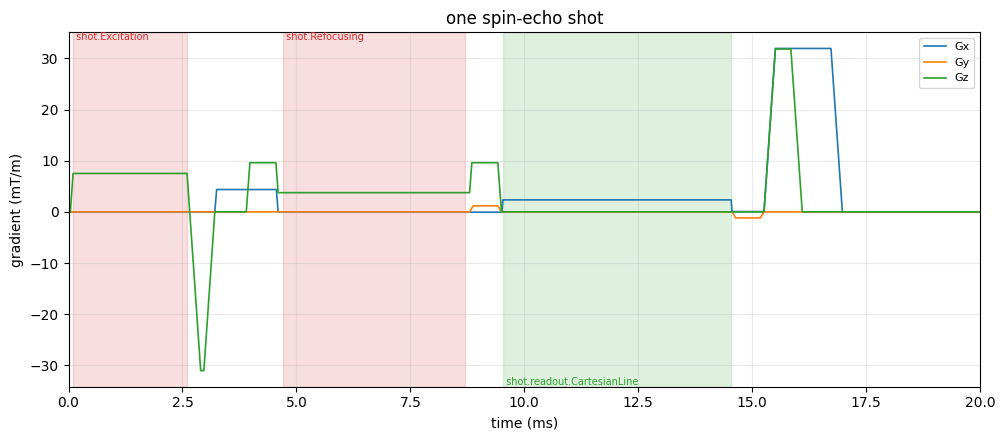

In [7]:
fig = sc.plot_block(one, opts, title='one spin-echo shot')
plt.xlim(0,20)

---
# Pass 2 — the same composition, written as `SE2D`

`SE2D` does **not** ship. One consumer — this notebook — and a composite with one consumer belongs
where that consumer is, the rule that kept `MPRAGE2D` and `MP2RAGE2D` out of the package too. What
*does* ship is `Refocusing`, because two notebook pairs use it and it is the obvious base for
SE-EPI, diffusion and T2 preparation.

**`ECO` is deliberately not emitted.** Every echo of a spin-echo shot goes into *one* image at a
different `ky`, so an echo counter would tell a reconstruction to split what belongs together.

In [8]:
class SE2D(sc.Module):
    """A single-echo 2D spin echo: one shot per line, stacked at TR."""

    def __init__(self, *, opts, fov_mm, matrix, thickness_mm, te_s=None, tr_s=None,
                 flip_deg=90.0, bandwidth_hz_px=200.0, partial_fourier=1.0,
                 excitation_duration_s=2.5e-3, refocus_duration_s=4e-3,
                 refocus_thickness_factor=1.25, crush_cycles_slice=3.0,
                 crush_cycles_readout=0.0, spoil_cycles_per_voxel=4.0,
                 spoil_axis=('x', 'z'), echoes=1, tag=None):
        super().__init__(opts=opts, tag=tag)
        fov_x, fov_y = (fov_mm, fov_mm) if np.isscalar(fov_mm) else fov_mm
        nx, ny = int(matrix[0]), int(matrix[1])
        self.fov_mm, self.matrix = (float(fov_x), float(fov_y)), (nx, ny)
        self.thickness_mm = float(thickness_mm)
        self.echoes = int(echoes)
        raster = sc.Raster(opts.grad_raster_time)
        self._block_raster = sc.Raster(opts.block_duration_raster)

        self.exc = sc.modules.Excitation(opts=opts, flip_deg=flip_deg,
                                         thickness_mm=self.thickness_mm,
                                         duration_s=excitation_duration_s)
        self.ro = sc.modules.CartesianLine(opts=opts, fov_mm=fov_x, matrix=nx, axis='x',
                                           bandwidth_hz_px=bandwidth_hz_px,
                                           partial_fourier=partial_fourier, prephase=False)
        # The two readout-axis lobes are a *balance*, not a crusher: their mean is
        # `crush_cycles_readout` (zero here) and only their difference -- one half-dwell's worth
        # of readout area -- is fixed.
        self.lobe_area_per_m = crush_cycles_readout / (self.fov_mm[0] / nx / 1e3)
        self.skew_per_m = (float(self.ro.gx.area) - 2 * self.ro.area_to_echo_per_m) / 2.0

        def refocusing(window_s):
            return sc.modules.Refocusing(
                opts=opts, thickness_mm=self.thickness_mm * refocus_thickness_factor,
                duration_s=refocus_duration_s, crush_cycles_per_voxel=crush_cycles_slice,
                crush_voxel_mm=self.thickness_mm, crush_duration_s=window_s)

        def encode(window_s):
            return sc.modules.PhaseEncode(opts=opts, fov_mm=fov_y, matrix=ny, axis='y',
                                          duration_s=window_s)

        # One window, three axes: GRE2DTR's winder coupling with the parts renamed.
        self.crush_min_s = {
            'z': refocusing(None).min_crush_duration_s,
            'x': max(float(pp.calc_duration(pp.make_trapezoid(
                'x', area=self.lobe_area_per_m + s, system=opts)))
                for s in (self.skew_per_m, -self.skew_per_m)),
            'y': encode(None).min_duration_s,
        }
        crush_s = float(raster.ceil(max(self.crush_min_s.values())))
        if te_s is not None:
            # Widening the window by d lengthens the echo spacing by exactly 2d: the echo moves by
            # d and time_to_crusher() - time_to_center() does not depend on the window at all.
            probe = refocusing(crush_s)
            base = 2 * (probe.time_to_crusher() - probe.time_to_center()
                        + crush_s + self.ro.time_to_echo())
            crush_s = float(raster.ceil(crush_s + max(0.0, (float(te_s) - base) / 2.0)))

        self.crush_s = crush_s
        self.refoc, self.pe = refocusing(crush_s), encode(crush_s)
        self.lobe_in = pp.make_trapezoid('x', area=self.lobe_area_per_m + self.skew_per_m,
                                         duration=crush_s, system=opts)
        self.lobe_out = pp.make_trapezoid('x', area=self.lobe_area_per_m - self.skew_per_m,
                                          duration=crush_s, system=opts)
        self.gx_s = float(pp.calc_duration(self.ro.gx))
        self.readout_s = 2 * crush_s + self.gx_s
        self.ro_start_s = self.refoc.time_to_crusher()

        self.dephase_area_per_m = float(self.lobe_in.area) + self.ro.area_to_echo_per_m
        dephaser_min_s = float(pp.calc_duration(pp.make_trapezoid(
            'x', area=self.dephase_area_per_m, system=opts)))
        train_s = 2 * (self.ro_start_s - self.refoc.time_to_center() + crush_s
                       + self.ro.time_to_echo())
        self.bounds_s = {
            'train': train_s,
            'first interval': 2 * ((self.exc().duration - self.exc.time_to_center())
                                   + max(0.0, dephaser_min_s - crush_s)
                                   + self.refoc.time_to_center()),
            'adc clearance': 2 * (self.ro_start_s + self.readout_s - crush_s - train_s / 2),
        }
        self.bound = max(self.bounds_s, key=self.bounds_s.get)
        half_s = float(raster.ceil(max(self.bounds_s.values()) / 2))
        self.echo_spacing_s = 2 * half_s
        # Whatever the train does not need, the echo still has to sit at the midpoint between its
        # two pulses -- the primary and stimulated pathways only coincide there.
        self.shift_s = float(raster.ceil(half_s - train_s / 2))
        self.t_refoc_s = float(raster.ceil(
            self.exc.time_to_center() + half_s - self.refoc.time_to_center()))
        dephaser_s = float(raster.ceil(max(dephaser_min_s, self.t_refoc_s + crush_s
                                           - self.exc().duration)))
        self.dephaser = pp.make_trapezoid('x', area=self.dephase_area_per_m,
                                          duration=dephaser_s, system=opts)

        self.spoilers = {axis: sc.modules.spoiler(opts, cycles_per_voxel=spoil_cycles_per_voxel,
                                                  voxel_mm=self.voxel_mm(axis), axis=axis)
                         for axis in spoil_axis}
        self.shot_s = (self.t_refoc_s + (self.echoes - 1) * self.echo_spacing_s
                       + self.ro_start_s + self.shift_s + self.readout_s
                       + max(block.duration for block in self.spoilers.values()))
        self.min_tr_s = float(self._block_raster.ceil(self.shot_s))
        if tr_s is not None and float(tr_s) < self.min_tr_s - 1e-12:
            raise sc.ConfigurationError(
                f'tr_s = {float(tr_s) * 1e3:.3f} ms is shorter than the {self.min_tr_s * 1e3:.3f} '
                f'ms this shot occupies, so the next excitation would land inside it.')
        self.tr_s = float(self._block_raster.ceil(max(tr_s or 0.0, self.min_tr_s)))

    # --------------------------------------------------------------- what it knows
    @property
    def center_line(self):
        return self.pe.center_line

    def voxel_mm(self, axis):
        """The voxel dimension along `axis`: fov/matrix in plane, the slice along z."""
        return {'x': self.fov_mm[0] / self.matrix[0], 'y': self.fov_mm[1] / self.matrix[1],
                'z': self.thickness_mm}[axis]

    def time_to_echo(self, echo=0):
        """Seconds from the start of a shot to echo `echo` -- what a tree cannot know."""
        return (self.t_refoc_s + echo * self.echo_spacing_s + self.ro_start_s + self.shift_s
                + self.crush_s + self.ro.time_to_echo())

    def te_s(self, echo=0):
        """Echo time: the excitation's effective centre to echo `echo`."""
        return self.time_to_echo(echo) - self.exc.time_to_center()

    # ------------------------------------------------------------------- assembly
    def build(self, *, lines, dummy_shots=0, center_mm=(0.0, 0.0, 0.0)):
        """One shot per line, stacked at TR, after `dummy_shots` that sample nothing."""
        table = self._check([[line] for line in lines])
        out = sc.LogicBlock()
        shots = [table[0]] * int(dummy_shots) + list(table)
        for n, segment in enumerate(shots):
            out.add(n * self.tr_s, self._shot(segment, segment_index=max(0, n - int(dummy_shots)),
                                              acquire=n >= int(dummy_shots),
                                              center_mm=center_mm))
        return out

    def _shot(self, lines, *, segment_index, acquire, center_mm):
        """One excitation and its echo train, as a block exactly `tr_s` long."""
        x, y, z = (float(v) for v in center_mm)
        if y != 0.0:
            raise sc.ConfigurationError(
                f'center_mm y = {y:g} mm is out of scope: a phase-encode shift is a per-line ADC '
                f'phase, not a per-shot frequency.')
        # Excite about +y, refocus about +x -- 90 degrees apart is the fixed point of the map a
        # refocusing pulse applies to transverse phase, and the receiver stays at 0.
        out = sc.LogicBlock('shot').add(0.0, self.exc(phase_deg=90.0, position_mm=z))
        out.add(self.t_refoc_s + self.crush_s - float(pp.calc_duration(self.dephaser)),
                self.dephaser)
        for n, line in enumerate(lines):
            t_ref = self.t_refoc_s + n * self.echo_spacing_s
            t_ro = t_ref + self.ro_start_s + self.shift_s
            out.add(t_ref, self.refoc(phase_deg=0.0, position_mm=z))
            out.add(t_ref + self.ro_start_s, self.pe(line=line))
            readout = sc.LogicBlock('readout').add(0.0, self.lobe_in)
            readout.add(self.crush_s, self.ro(acquire=acquire, offset_mm=x))
            readout.add(self.crush_s + self.gx_s, self.lobe_out)
            out.add(t_ro, readout)
            out.add(t_ro + self.readout_s - self.crush_s, self.pe(line=line, rewind=True))
            if acquire:
                out.add(t_ro, pp.make_label(type='SET', label='LIN', value=int(line)))
                if n == 0:
                    out.add(t_ro, pp.make_label(type='SET', label='SEG',
                                                value=int(segment_index)))
        for block in self.spoilers.values():
            out.add(t_ro + self.readout_s, block)
        fill = float(self._block_raster.ceil(self.tr_s - self.shot_s))
        if fill > 1e-9:
            out.add(self.shot_s, pp.make_delay(fill))
        return out

    # ---------------------------------------------------------------- the refusals
    def _check(self, table):
        """What the compiler cannot see: an out-of-range line, a repeat, a missing k = 0."""
        table = [[int(line) for line in segment] for segment in table]
        if not table or not all(table):
            raise sc.ConfigurationError('lines must be a non-empty table of non-empty shots')
        seen = [line for segment in table for line in segment]
        outside = sorted({line for line in seen if not 0 <= line < self.matrix[1]})
        if outside:
            raise sc.ConfigurationError(
                f'{len(outside)} line(s) fall outside 0 ... {self.matrix[1] - 1}: {outside[:8]}.')
        repeated = sorted({line for line in seen if seen.count(line) > 1})
        if repeated:
            raise sc.ConfigurationError(
                f'{len(repeated)} line(s) are acquired more than once: {repeated[:8]}.  Two '
                f'readouts writing one k-space address is what the compiler rejects downstream, '
                f'with less to say about it than here.')
        if self.center_line not in seen:
            warnings.warn(f'no shot acquires the centre line {self.center_line}, so the image has '
                          f'no DC term.', sc.SeqCraftWarning, stacklevel=3)
        return table


se = SE2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM, tr_s=TR_S,
          bandwidth_hz_px=BANDWIDTH_HZ_PX, excitation_duration_s=EXCITE_DURATION_S,
          refocus_duration_s=REFOCUS_DURATION_S, refocus_thickness_factor=REFOCUS_FACTOR,
          crush_cycles_slice=CRUSH_CYCLES_SLICE, crush_cycles_readout=CRUSH_CYCLES_READOUT,
          spoil_cycles_per_voxel=SPOIL_CYCLES, spoil_axis=SPOIL_AXIS)

print(se(lines=[CENTER_LINE]))
print(f'echo spacing {se.echo_spacing_s * 1e3:.3f} ms ({se.bound}-bound)   '
      f'TE {se.te_s() * 1e3:.3f} ms   TR {se.tr_s:.3f} s   min TR {se.min_tr_s * 1e3:.3f} ms')

LogicBlock(SE2D, 1 node, 2000.00 ms)
echo spacing 10.700 ms (train-bound)   TE 10.702 ms   TR 2.000 s   min TR 16.980 ms


### The class is the loop, and nothing else — plus five checks on the whole scan

Each check catches a different way the sequence can be wrong while still compiling. The compile
produces two warnings, and the last check pins them by content so a real one cannot hide inside an
expected one.

In [9]:
lines = tuple(range(NY))
scan = scan_inline(lines)


def event_digest(tree):
    """Every leaf event as (absolute time, content hash), tags and nesting ignored."""
    return sorted((round(t, 12), sc.events.content_hash(e)) for t, e, _ in sc.flatten(tree))


assert event_digest(scan) == event_digest(se(lines=lines))
assert event_digest(scan_inline(lines[:4], dummy_shots=2)) == \
    event_digest(se(lines=lines[:4], dummy_shots=2))

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always', sc.SeqCraftWarning)
    seq = sc.compile(scan, opts, name='se_2d')
k = sc.kspace(scan, opts)
k_adc = k['k_adc'].reshape(3, NY, ro.num_samples)

# 1. k = 0 on x and z, and k_y on the requested line, at the echo *sample* of every readout
at_echo = k_adc[:, :, ro.pre_echo_samples]
want_y = (np.asarray(lines) - CENTER_LINE) * DK_Y
worst = max(np.abs(at_echo[0]).max(), np.abs(at_echo[2]).max(), np.abs(at_echo[1] - want_y).max())
assert worst < 1e-6, worst
# 2. the measured TE is the one the arithmetic predicted
measured_te = k['t_adc'][ro.pre_echo_samples] - float(k['t_excitation'][0])
assert abs(measured_te - se.te_s()) < 1e-9
# 3. the refocusing pulse is where time_to_center says it is
assert abs(float(k['t_refocusing'][0]) - (t_refoc_s + refoc.time_to_center())) < 1e-9
# 4. nothing survives one shot on y: the rewinder rewinds
assert abs(sc.moments(shot_inline([3]))['y']) < 1e-9
# 5. z is quiet while the ADC is open -- signal loss rather than a k-space error, so nothing
#    above would catch it
grid, grads, marks = sc.sample(shot_inline([CENTER_LINE]), opts)
open_adc = np.zeros_like(grid, dtype=bool)
for kind, start, end, _ in marks:
    if kind == 'adc':
        open_adc |= (grid >= start) & (grid < end)
assert np.abs(grads['z'][open_adc]).max() < 1e-9

print('the class and the loop are the same events, acquired and dummy')
print(f'{len(seq.block_events)} pulseq blocks, {seq.duration()[0] / 60:.2f} min, '
      f'{len(seq.block_events) / NY:.1f} blocks per line')
print(f'worst |k| at the echo over {NY} readouts   {worst:.3e} 1/m')
print(f'TE measured {measured_te * 1e3:.4f} ms   (predicted {se.te_s() * 1e3:.4f} ms)')
print(f'z while the ADC is open  {np.abs(grads["z"][open_adc]).max():.2e} Hz/m')
for warning in caught:
    print(f'expected: {str(warning.message).splitlines()[0][:92]}')
assert len(caught) == 2
assert 'same-axis gradient merges' in str(caught[0].message)
assert 'vector-norm limit' in str(caught[1].message)

E:\MGH\SeqCraft\src\seqcraft\design\module.py:217: SeqCraftWarning: no shot acquires the centre line 64, so the image has no DC term.
  return self._finalize(self.build(*args, **kwargs))


the class and the loop are the same events, acquired and dummy
896 pulseq blocks, 4.27 min, 7.0 blocks per line
worst |k| at the echo over 128 readouts   2.016e-07 1/m
TE measured 10.7020 ms   (predicted 10.7019 ms)
z while the ADC is open  0.00e+00 Hz/m
expected: 128 same-axis gradient merges: SE2D.shot+SE2D.shot.readout (axis x) x128
expected: 384 blocks over the vector-norm limit (legal on real amplifiers): SE2D.shot, SE2D.shot.Phase


E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 128 same-axis gradient merges: SE2D.shot+SE2D.shot.readout (axis x) x128
  seq = compile_sequence(tree, opts)
E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 384 blocks over the vector-norm limit (legal on real amplifiers): SE2D.shot, SE2D.shot.PhaseEncode, SE2D.shot.Refocusing, SE2D.shot.readout (slew 129% at 3.210 ms), SE2D.shot.spoiler (grad 141% at 15.260 ms), SE2D.shot.spoiler (slew 139% at 15.260 ms), SE2D.shot, SE2D.shot.PhaseEncode, SE2D.shot.Refocusing, SE2D.shot.readout (slew 128% at 2003.210 ms), SE2D.shot.spoiler (grad 141% at 2015.260 ms) (+379 more sites)
  seq = compile_sequence(tree, opts)


> The first warning is the readout's trailing lobe sharing a block with the tail spoiler on the
> same axis — an exact superposition of gradients that do not overlap in time. The second is three
> axes ramping together at per-axis slew limits: legal on a real amplifier, over the vector norm.

### The refusals, each shown once

In [10]:
def refused(what, call):
    try:
        call()
    except sc.ConfigurationError as error:
        print(f'{what}\n  {str(error).splitlines()[0]}\n')
    else:
        raise AssertionError(f'{what} was not refused')


refused('a 2 ms 180, which is over max_b1 and which sc.compile would not catch',
        lambda: sc.modules.Refocusing(opts=opts, thickness_mm=6.25, duration_s=2e-3))
refused('asking a prephase=False readout for its prephaser', lambda: ro.prephaser_area_per_m)
refused('a crusher window shorter than the area it has to carry',
        lambda: sc.modules.Refocusing(opts=opts, thickness_mm=6.25, crush_duration_s=100e-6))
refused('a line acquired twice', lambda: se(lines=[3, 3]))
refused('a TR shorter than the shot',
        lambda: SE2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                     tr_s=5e-3))

a 2 ms 180, which is over max_b1 and which sc.compile would not catch
  a 2 ms 180 degree sinc pulse peaks at 130 % of max_b1.

asking a prephase=False readout for its prephaser
  this readout has no prephaser, because prephase=False.

a crusher window shorter than the area it has to carry
  crush_duration_s = 100.0 us is shorter than the minimum this crusher needs.

a line acquired twice
  1 line(s) are acquired more than once: [3].  Two readouts writing one k-space address is what the compiler rejects downstream, with less to say about it than here.

a TR shorter than the shot
  tr_s = 5.000 ms is shorter than the 16.980 ms this shot occupies, so the next excitation would land inside it.



---
## The file

`seq/se_2d.seq`, with the definitions a reconstruction reads back and the nominal k-space beside it
so [`02`](02_simulate_and_reconstruct.ipynb) can check the parsed trajectory against what was
intended.

In [11]:
definitions = {
    'FOV': [FOV_MM[0] / 1e3, FOV_MM[1] / 1e3, THICKNESS_MM / 1e3],
    'SliceThickness': THICKNESS_MM / 1e3,
    'kSpaceCenterLine': CENTER_LINE,
    'TE': se.te_s(),
    'TR': se.tr_s,
    'ReceiverBandwidth': BANDWIDTH_HZ_PX,
}

with warnings.catch_warnings():
    warnings.simplefilter('ignore', sc.SeqCraftWarning)
    tree = se(lines=lines)
    seq = sc.compile(tree, opts, name='se_2d', definitions=definitions)
    seq.write(str(SEQ_DIR / 'se_2d.seq'))
    nominal = sc.kspace(tree, opts)['k_adc'].reshape(3, NY, ro.num_samples)

np.savez(
    SEQ_DIR / 'se_2d_nominal.npz',
    matrix=np.array(MATRIX), fov_mm=np.array(FOV_MM), thickness_mm=THICKNESS_MM,
    center_line=CENTER_LINE, lines=np.array(lines), k=nominal,
    te_s=se.te_s(), tr_s=se.tr_s, echo_spacing_s=se.echo_spacing_s,
    bandwidth_hz_px=BANDWIDTH_HZ_PX, excite_duration_s=EXCITE_DURATION_S,
    refocus_duration_s=REFOCUS_DURATION_S, refocus_factor=REFOCUS_FACTOR,
    crush_cycles_slice=CRUSH_CYCLES_SLICE, crush_cycles_readout=CRUSH_CYCLES_READOUT,
    spoil_cycles=SPOIL_CYCLES,
)
print(f'-> {SEQ_DIR / "se_2d.seq"}   {len(seq.block_events)} blocks, '
      f'{seq.duration()[0] / 60:.2f} min')
print(f'   k_x at the echo {np.abs(nominal[0, :, ro.pre_echo_samples]).max():.2e} 1/m')
print(f'-> {SEQ_DIR / "se_2d_nominal.npz"}')

-> seq\se_2d.seq   896 blocks, 4.27 min
   k_x at the echo 1.75e-07 1/m
-> seq\se_2d_nominal.npz


E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 1 same-axis gradient merge: SE2D.shot+SE2D.shot.readout (axis x)
  seq = compile_sequence(tree, opts)
E:\MGH\SeqCraft\src\seqcraft\analysis.py:201: SeqCraftWarning: 3 blocks over the vector-norm limit (legal on real amplifiers): SE2D.shot, SE2D.shot.PhaseEncode, SE2D.shot.Refocusing, SE2D.shot.readout (slew 111% at 3.210 ms), SE2D.shot.spoiler (grad 141% at 15.260 ms), SE2D.shot.spoiler (slew 139% at 15.260 ms)
  seq = compile_sequence(tree, opts)


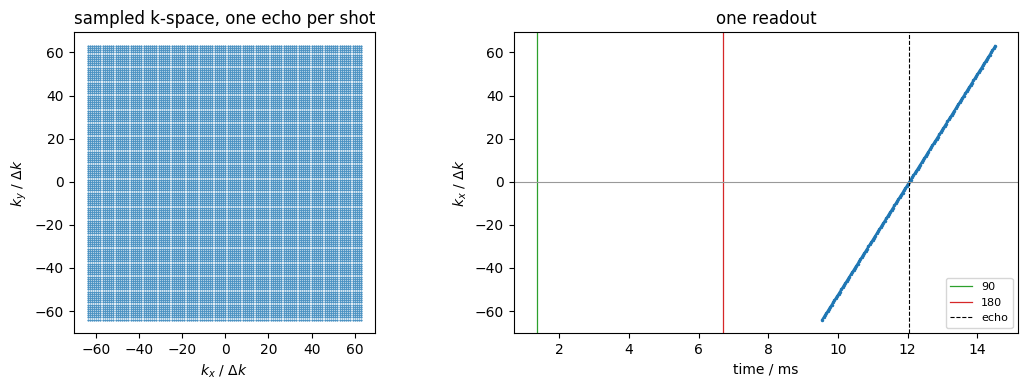

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
axes[0].plot(nominal[0] / DK_X, nominal[1] / DK_Y, '.', ms=1.0, color='C0')
axes[0].set(xlabel='$k_x$ / $\\Delta k$', ylabel='$k_y$ / $\\Delta k$',
            title='sampled k-space, one echo per shot')
axes[0].set(aspect='equal')
t = sc.kspace(se(lines=[CENTER_LINE]), opts)
axes[1].plot(t['t_adc'] * 1e3, t['k_adc'][0] / DK_X, '.-', ms=3)
axes[1].axvline(t['t_excitation'][0] * 1e3, color='C2', lw=0.9, label='90')
axes[1].axvline(t['t_refocusing'][0] * 1e3, color='C3', lw=0.9, label='180')
axes[1].axvline(t['t_adc'][ro.pre_echo_samples] * 1e3, color='k', lw=0.8, ls='--', label='echo')
axes[1].axhline(0, color='0.6', lw=0.8)
axes[1].set(xlabel='time / ms', ylabel='$k_x$ / $\\Delta k$', title='one readout')
axes[1].legend(fontsize=8)
fig.tight_layout()

---
## What this notebook established

| | |
|---|---|
| **area before the echo equals area after it**, per axis, between refocusing centres | the whole sequence family is that one rule, and `sc.kspace` applies the conjugation itself |
| the readout needs **no prephaser** | its dephasing is half of a pair straddling a *refocusing pulse*, and the two halves live in different readout blocks |
| only the **difference** between the two `x` lobes is fixed, and it is not optional | it is the half dwell the prephaser carries, split two ways. Their common area *is* optional, is free in k-space, and is zero here: the crusher belongs on the slice axis |
| **equal-area crushers means measured to the RF's effective centre** | not the same trapezoid twice — that residual alternates sign echo to echo and reads as a hardware fault |
| the plateau is **symmetrised about the centre** as well as balanced | the area solve makes k exact; only the time symmetry puts the echo at the midpoint |
| the excitation, the phase encoding and the spoiler need **no change at all** | two modules and one function serving a sequence family they were not written for is the test the library set itself |
| the readout block starts at **`time_to_crusher()`**, inside the refocusing block | worth 1.4 ms per echo and 30 pulseq blocks per eight |
| three minima on the echo spacing | the train, the first interval, and **`z` clearance under the ADC** — the last is signal loss, which none of the k-space checks can see |

**`dummy_shots` is `0` here, and that is a property of one echo per shot.** Shot 0 starts from
thermal equilibrium and every later shot starts from whatever a 2 s TR recovered to — about 11 %
lower. With one line per shot that is *one* line, at the very edge of k-space, and the difference is
a monotone trend rather than a pattern. Give each shot sixteen lines spread across `ky` and the same
difference becomes a comb, which is a **replica of the object** — which is why
[`../fse_2d/`](../fse_2d/01_build.ipynb) builds with a run-in.

Next: [`../fse_2d/01_build.ipynb`](../fse_2d/01_build.ipynb) turns the one echo into sixteen and then
seventy-two, and [`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) asks
whether this really is a **T2** echo.